# Detección de Primeros Fraudes en Tarjeta
Dataset: BO-VIP (Bolivia) | Modelo: LightGBM con métricas `feval` personalizadas

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

In [96]:

DATA_PATH = r'Copia de Datasets 3 bancos/Copia de 01_bo_vip_seed22_n100000.csv'

---
## Carga y Parseo de Fechas

In [97]:
df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)
print(f'Shape original: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Shape original: (100003, 66)
Columnas: ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE54_a

In [98]:
# DE13_local_date está en formato MMDD (ej: 1231 = diciembre 31)
# DE12_local_time está en formato HHMMSS (ej: 200151 = 20:01:51)
df['local_month'] = (df['DE13_local_date'] // 100).astype(int)
df['local_day']   = (df['DE13_local_date'] % 100).astype(int)

# Diciembre 2024 aparece como mes 12 (transacciones que localmente son 31-dic-2024)
df['year'] = np.where(df['local_month'] == 12, 2024, 2025)

# Reconstruir timestamp completo
time_str = (df['DE12_local_time'].astype(int).astype(str)
              .str.zfill(6))
df['tx_datetime'] = pd.to_datetime(
    df['year'].astype(str) +
    df['local_month'].astype(str).str.zfill(2) +
    df['local_day'].astype(str).str.zfill(2) + ' ' +
    time_str.str[:2] + ':' + time_str.str[2:4] + ':' + time_str.str[4:],
    format='%Y%m%d %H:%M:%S',
    errors='coerce'
)

print(f'Nulls en tx_datetime: {df["tx_datetime"].isna().sum()}')
print(f'Rango de fechas: {df["tx_datetime"].min()} → {df["tx_datetime"].max()}')
print(f'\nTransacciones por mes:')
print(df['local_month'].value_counts().sort_index())

Nulls en tx_datetime: 0
Rango de fechas: 2024-12-31 20:01:51 → 2025-06-29 20:13:36

Transacciones por mes:
local_month
1     17230
2     15664
3     17133
4     16610
5     17199
6     16073
12       94
Name: count, dtype: int64



DE13 (local_date) almacena la fecha local del comercio en formato MMDD, un entero de 4 dígitos donde los primeros dos son el mes y los últimos dos el día. Ejemplo: 0615 = 15 de junio. No incluye el año porque originalmente era un campo de 4 bytes para tarjetas magnéticas.

DE12 (local_time) almacena la hora local en formato HHMMSS, un entero de 6 dígitos. Ejemplo: 142305 = 14:23:05.

Por eso hacemos DE13 // 100 para extraer el mes y DE13 % 100 para el día, y reconstruimos el timestamp completo concatenando ambos campos.

In [99]:
# Orden cronológicamente
df = df.sort_values('tx_datetime').reset_index(drop=True)
print(f'Dataset ordenado. Primeras fechas:')
print(df[['tx_datetime', 'client_id', 'amount_usd', 'is_fraud']].head(5))

Dataset ordenado. Primeras fechas:
          tx_datetime           client_id  amount_usd  is_fraud
0 2024-12-31 20:01:51  BO-VIP-CL-00001325    500.1200     False
1 2024-12-31 20:03:55  BO-VIP-CL-00000079   1898.9300     False
2 2024-12-31 20:04:10  BO-VIP-CL-00002344    349.8500     False
3 2024-12-31 20:04:53  BO-VIP-CL-00002587    345.5800     False
4 2024-12-31 20:07:56  BO-VIP-CL-00000087    118.9000     False


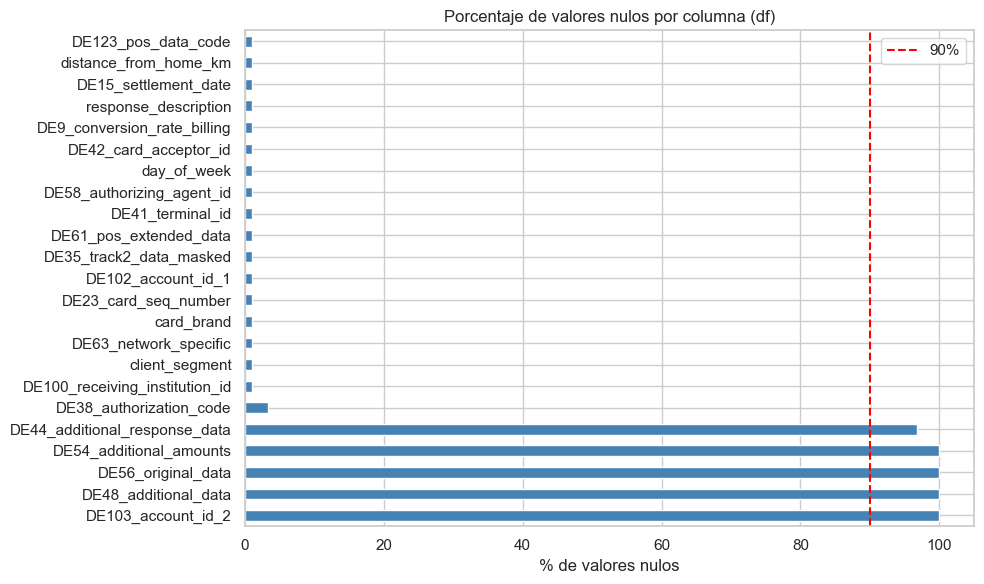

In [100]:
null_pct = df.isnull().mean() * 100
null_pct = null_pct.sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
null_pct_nonzero.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por columna (df)")
ax.axvline(90, color="red", linestyle="--", label="90%")
ax.legend()
plt.tight_layout()
plt.show()

In [101]:
print("\nColumnas con >90% nulos:")
print(null_pct[null_pct > 90].index.tolist())


Columnas con >90% nulos:
['DE103_account_id_2', 'DE48_additional_data', 'DE56_original_data', 'DE54_additional_amounts', 'DE44_additional_response_data']


In [102]:
COLS_DROP_NULL = [
    "DE56_original_data",       
    "DE103_account_id_2",       
    "DE54_additional_amounts",  
    "DE48_additional_data",     
    "DE44_additional_response_data",
]

---
## EDA

Distribución Temporal y Primeros Fraudes

Total transacciones: 100,003
Fraudes: 4,919 (4.92%)


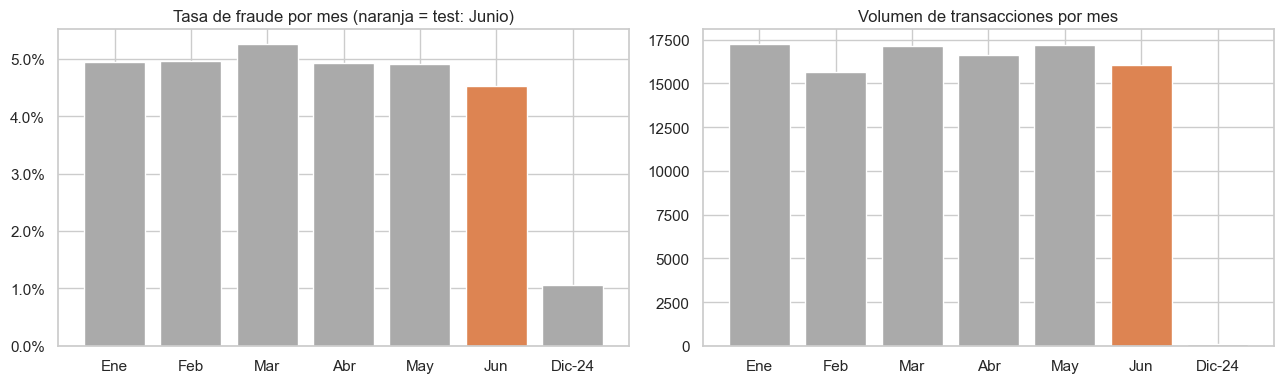

In [103]:
# Distribución de fraude
fraud_rate = df['is_fraud'].mean()
print(f'Total transacciones: {len(df):,}')
print(f'Fraudes: {df["is_fraud"].sum():,} ({fraud_rate:.2%})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

month_labels = {12: 'Dic-24', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun'}
fraud_by_month = df.groupby('local_month')['is_fraud'].mean()
idx = fraud_by_month.index.tolist()
axes[0].bar(range(len(idx)), fraud_by_month.values, color=['#aaa' if m != 6 else '#dd8452' for m in idx])
axes[0].set_xticks(range(len(idx)))
axes[0].set_xticklabels([month_labels.get(m, str(m)) for m in idx])
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Tasa de fraude por mes (naranja = test: Junio)')

vol_by_month = df.groupby('local_month').size()
axes[1].bar(range(len(vol_by_month)), vol_by_month.values,
            color=['#aaa' if m != 6 else '#dd8452' for m in vol_by_month.index])
axes[1].set_xticks(range(len(vol_by_month)))
axes[1].set_xticklabels([month_labels.get(m, str(m)) for m in vol_by_month.index])
axes[1].set_title('Volumen de transacciones por mes')

plt.tight_layout()
plt.show()

Tarjetas con al menos un fraude: 1,520

Distribución de en qué # de transacción ocurre el primer fraude:
count   1520.0000
mean      11.8178
std        7.4640
min        1.0000
25%        6.0000
50%       11.0000
75%       17.0000
max       40.0000
Name: card_txn_number, dtype: float64


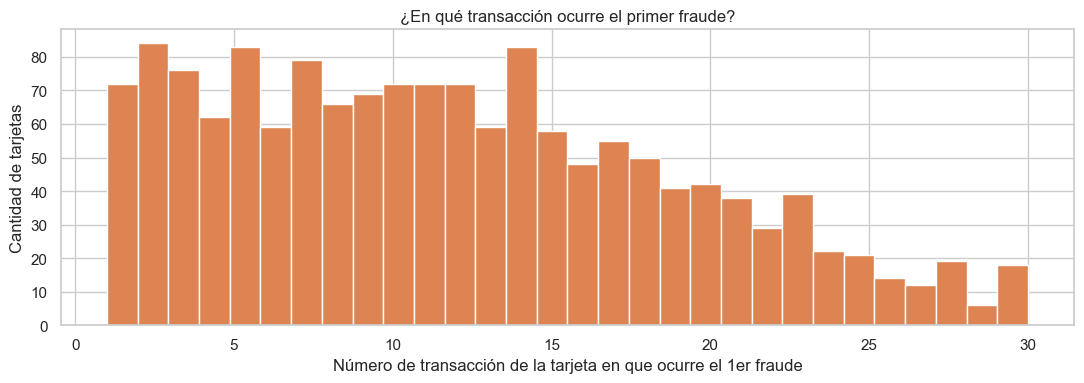

In [104]:
# Analizamos en qué transacción de la tarjeta ocurre el primer fraude
# identifiacar cada transacción por pan_hash (tarjeta) en orden temporal
df['card_txn_number'] = df.groupby('pan_hash').cumcount() + 1

# Identificar el PRIMER fraude de cada tarjeta
fraud_txns = df[df['is_fraud'] == True].copy()
first_fraud_per_card = fraud_txns.groupby('pan_hash')['card_txn_number'].min()

print(f'Tarjetas con al menos un fraude: {len(first_fraud_per_card):,}')
print(f'\nDistribución de en qué # de transacción ocurre el primer fraude:')
print(first_fraud_per_card.describe())

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(first_fraud_per_card.clip(upper=30), bins=30, color='#dd8452', edgecolor='white')
ax.set_xlabel('Número de transacción de la tarjeta en que ocurre el 1er fraude')
ax.set_ylabel('Cantidad de tarjetas')
ax.set_title('¿En qué transacción ocurre el primer fraude?')
plt.tight_layout()
plt.show()


In [105]:
pct_early = (first_fraud_per_card <= 10).mean()
print(f'{pct_early:.1%}')
pct_early = (first_fraud_per_card <= 5).mean()
print(f'{pct_early:.1%}')

pct_first = (first_fraud_per_card <= 1).mean()
print(f'{pct_first:.1%}')

47.5%
24.8%
4.7%


24.8% de los primeros fraudes ocurren en las primeras 5 transacciones de la tarjeta y 4.7% del primer fraude ocurren en la PRIMERA transacción. 

### Otros análisis

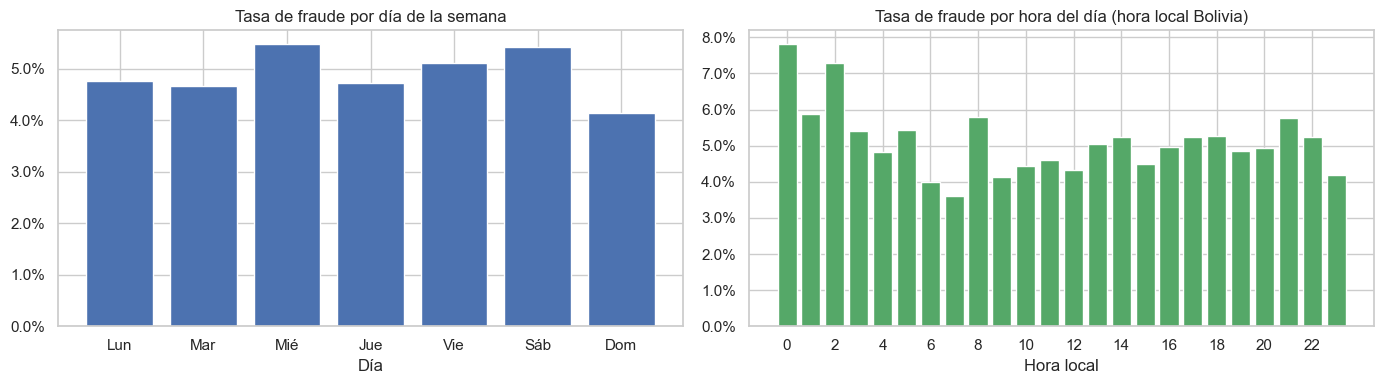

In [106]:
# Tasa de fraude por día de la semana y por hora del día
DAY_ORDER = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
DAY_ES    = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fraud_day  = df.groupby('day_of_week')['is_fraud'].mean().reindex(DAY_ORDER)
fraud_hour = df.groupby('hour_local')['is_fraud'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(DAY_ORDER)), fraud_day.values, color='#4c72b0')
axes[0].set_xticks(range(len(DAY_ORDER)))
axes[0].set_xticklabels(DAY_ES)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Tasa de fraude por día de la semana')
axes[0].set_xlabel('Día')

axes[1].bar(fraud_hour.index, fraud_hour.values, color='#55a868')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('Tasa de fraude por hora del día (hora local Bolivia)')
axes[1].set_xlabel('Hora local')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

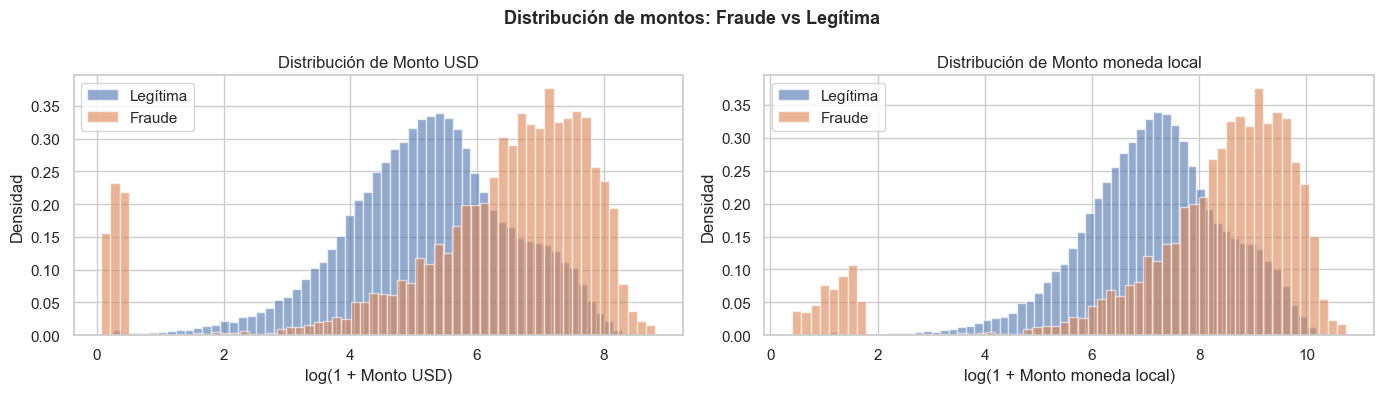

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes,
                           ["amount_usd", "amount_local"],
                           ["Monto USD", "Monto moneda local"]):
    for fraud_val, color, lbl in [(0, "#4c72b0", "Legítima"), (1, "#dd8452", "Fraude")]:
        subset = df[df["is_fraud"] == fraud_val][col]
        # logarithmic bin histogram
        data = subset[subset > 0]
        ax.hist(np.log1p(data), bins=60, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_xlabel(f"log(1 + {label})")
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de {label}")
    ax.legend()

plt.suptitle("Distribución de montos: Fraude vs Legítima", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

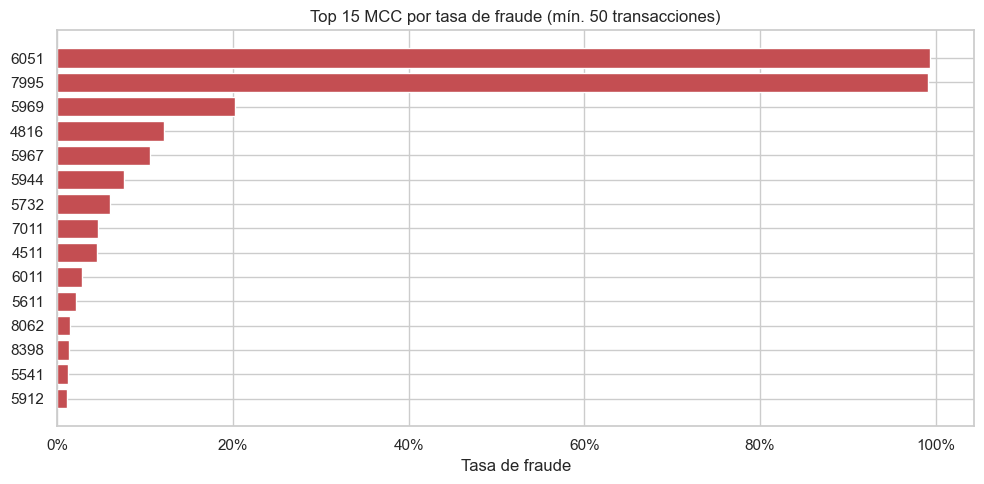

                             fraud_rate   n_tx
DE18_merchant_category_code                   
6051                             0.9939    328
7995                             0.9912    340
5969                             0.2028   2234
4816                             0.1216   5106
5967                             0.1059   5979
5944                             0.0758   4918
5732                             0.0604  11018
7011                             0.0458   9064
4511                             0.0450   9192
6011                             0.0284   9725
5611                             0.0217   1106
8062                             0.0143   1118
8398                             0.0135    296
5541                             0.0123   1140
5912                             0.0115   1220


In [108]:
# Top 15 MCC por tasa de fraude (mín. 50 transacciones)
top_mcc = (
    df.groupby('DE18_merchant_category_code')
      .agg(fraud_rate=('is_fraud', 'mean'), n_tx=('is_fraud', 'count'))
      .query('n_tx >= 50')
      .sort_values('fraud_rate', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_mcc.index.astype(str), top_mcc['fraud_rate'], color='#c44e52')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Top 15 MCC por tasa de fraude (mín. 50 transacciones)')
ax.set_xlabel('Tasa de fraude')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(top_mcc.to_string())

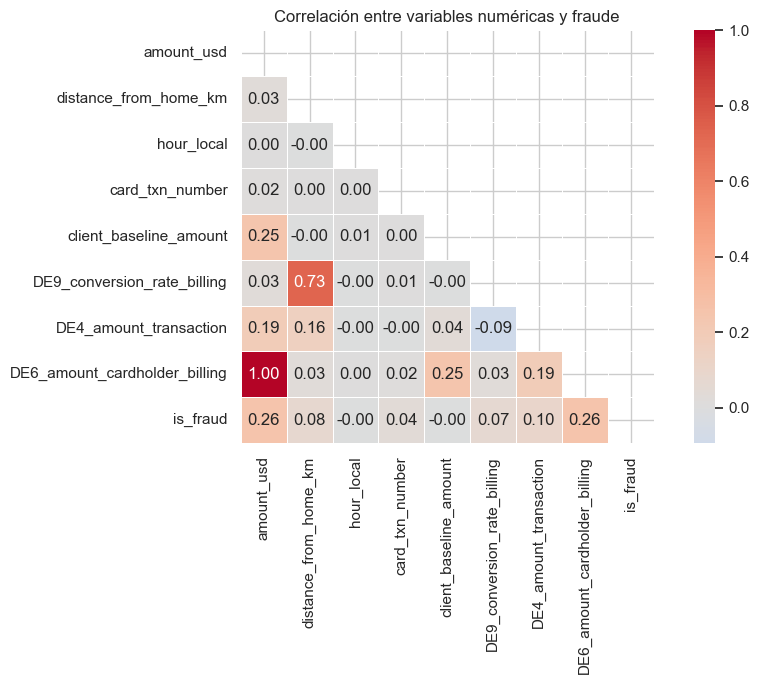

In [109]:
# Correlación de variables numéricas con is_fraud
NUM_COLS = [
    'amount_usd', 'distance_from_home_km', 'hour_local', 'card_txn_number',
    'client_baseline_amount', 'DE9_conversion_rate_billing',
    'DE4_amount_transaction', 'DE6_amount_cardholder_billing',
]
corr_df = df[[c for c in NUM_COLS if c in df.columns] + ['is_fraud']].copy()
corr_df['is_fraud'] = corr_df['is_fraud'].astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre variables numéricas y fraude')
plt.tight_layout()
plt.show()

---
## Feature Engineering

Features de velocidad y comportamiento del cliente a lo largo del tiempo

**minutos desde la transacción anterior del cliente**

In [110]:
df['prev_tx_datetime'] = df.groupby('client_id')['tx_datetime'].shift(1)
df['time_since_last_txn_min'] = (
    (df['tx_datetime'] - df['prev_tx_datetime']).dt.total_seconds() / 60
)
# Primera transacción del cliente → -1 (sin historial)
df['time_since_last_txn_min'] = df['time_since_last_txn_min'].fillna(-1)

print('time_since_last_txn_min:')
print(df[df['time_since_last_txn_min'] >= 0]['time_since_last_txn_min'].describe())

time_since_last_txn_min:
count    96003.0000
mean      9921.0914
std      10172.4451
min          0.1667
25%       2643.8667
50%       6854.0500
75%      13920.2167
max     126570.5167
Name: time_since_last_txn_min, dtype: float64


 txn_count_last_1h y txn_count_last_24h por cliente


In [111]:
# merge-asof sobre ventanas temporales
def count_in_window(df, client_col, time_col, window_minutes):
    """Para cada fila, cuenta cuántas transacciones tuvo el cliente
    en los `window_minutes` minutos anteriores (sin incluir la actual)."""
    results = np.zeros(len(df), dtype=int)
    df_sorted = df[[client_col, time_col]].copy()
    
    for client_id, grp in df_sorted.groupby(client_col):
        times = grp[time_col].values
        idx   = grp.index.values
        window_ns = np.timedelta64(window_minutes, 'm')
        for i, (t, ix) in enumerate(zip(times, idx)):
            # contar transacciones anteriores dentro de la ventana
            cutoff = t - window_ns
            count = np.sum((times[:i] >= cutoff) & (times[:i] < t))
            results[ix] = count
    return results

df['txn_count_last_1h']  = count_in_window(df, 'client_id', 'tx_datetime', 60)
df['txn_count_last_24h'] = count_in_window(df, 'client_id', 'tx_datetime', 1440)

print('\nDistribución txn_count_last_1h (fraude vs legítima):')
print(df.groupby('is_fraud')[['txn_count_last_1h', 'txn_count_last_24h']].mean())


Distribución txn_count_last_1h (fraude vs legítima):
          txn_count_last_1h  txn_count_last_24h
is_fraud                                       
False                0.0064              0.1388
True                 1.0378              1.6243


**z-score del monto vs historial PREVIO del cliente**

In [112]:
# Usar expanding() para no incluir datos futuros (sin data leakage)
df['client_expanding_mean'] = (
    df.groupby('client_id')['amount_usd']
      .transform(lambda x: x.expanding().mean().shift(1))
)
df['client_expanding_std'] = (
    df.groupby('client_id')['amount_usd']
      .transform(lambda x: x.expanding().std().shift(1))
)
df['amount_zscore_customer'] = (
    (df['amount_usd'] - df['client_expanding_mean'])
    / (df['client_expanding_std'].fillna(1) + 1e-6)
)
df['amount_zscore_customer'] = df['amount_zscore_customer'].fillna(0)

print('amount_zscore_customer por clase:')
print(df.groupby('is_fraud')['amount_zscore_customer'].describe().T)

amount_zscore_customer por clase:
is_fraud       False      True 
count     95084.0000  4919.0000
mean          0.9687    10.0099
std         198.3429   139.2113
min      -38451.9786 -2362.6276
25%          -0.6831    -0.1690
50%          -0.3804     0.9522
75%           0.2728     2.6099
max       11547.0218  3857.8861


---
## Features de Detección de Primeros Fraudes en Tarjeta

**Número de transacción del cliente y de la tarjeta**

In [113]:
df['client_txn_number'] = df.groupby('client_id').cumcount() + 1
df['client_txn_number'].describe()

count   100003.0000
mean        13.5695
std          8.1638
min          1.0000
25%          7.0000
50%         13.0000
75%         20.0000
max         46.0000
Name: client_txn_number, dtype: float64

**Flags de primeras transacciones**

In [114]:
df['is_first_card_txn'] = (df['card_txn_number'] == 1).astype(int)
df['is_early_card_txn'] = (df['card_txn_number'] <= 5).astype(int)
df['is_new_client'] = (df['client_txn_number'] <= 3).astype(int)
df['is_new_client']

0         1
1         1
2         1
3         1
4         1
         ..
99998     0
99999     0
100000    0
100001    0
100002    0
Name: is_new_client, Length: 100003, dtype: int64

**Días desde la primera transacción de esta tarjeta**

In [115]:
card_first_txn = df.groupby('pan_hash')['tx_datetime'].transform('min')
# 86400 son los segundos en 24 h
df['card_age_days'] = (df['tx_datetime'] - card_first_txn).dt.total_seconds() / 86400
df['card_age_days'].describe()

count   100003.0000
mean        82.9571
std         51.9994
min          0.0000
25%         37.5654
50%         82.7261
75%        127.6169
max        179.9697
Name: card_age_days, dtype: float64

**Monto relativo al promedio de la tarjeta**

In [116]:
df['card_expanding_mean'] = (
    df.groupby('pan_hash')['amount_usd']
      .transform(lambda x: x.expanding().mean().shift(1))
)
df['amount_vs_card_avg'] = (
    df['amount_usd'] / (df['card_expanding_mean'].fillna(df['amount_usd']) + 1e-6)
)

# Verificación
print('Tasa de fraude por tramo de card_txn_number:')
df['card_txn_bucket'] = pd.cut(df['card_txn_number'], [0,1,3,5,10,20,50,1000],
                                labels=['1','2-3','4-5','6-10','11-20','21-50','51+'])
print(df.groupby('card_txn_bucket', observed=True)['is_fraud'].agg(['mean','count'])
        .rename(columns={'mean':'fraud_rate','count':'n_tx'}))

Tasa de fraude por tramo de card_txn_number:
                 fraud_rate   n_tx
card_txn_bucket                   
1                    0.0180   4000
2-3                  0.0330   8000
4-5                  0.0441   8000
6-10                 0.0492  19999
11-20                0.0516  38325
21-50                0.0586  21679


**Canal, monto, ubicación del resto de fraudes**

In [117]:
df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)
df['is_night'] = df['hour_local'].between(0, 5).astype(int)

df['is_online'] = df['DE22_pos_entry_mode'].isin([81, '81', '081']).astype(int)
df['is_cnp'] = ( df['DE22_pos_entry_mode'].isin([81, 10, '81', '010', '081']) | df['DE25_pos_condition_code'].isin([59, '59']) ).astype(int)
df['pin_used'] = (df['DE52_pin_data_present'].astype(str).str.upper() == 'Y').astype(int)
df['emv_used'] = (df['DE55_emv_data_present'].astype(str).str.upper() == 'Y').astype(int)

df['is_international'] = df['is_international'].astype(int)
df['distance_log'] = np.log1p(df['distance_from_home_km'].fillna(0))
df['high_distance'] = (df['distance_from_home_km'].fillna(0) > 500).astype(int)

df['amount_usd_log'] = np.log1p(df['amount_usd'])
df['amount_ratio_baseline'] = df['amount_usd'] / (df['client_baseline_amount'] + 1)

df['has_conversion'] = (df['DE9_conversion_rate_billing'] != 1.0).astype(int)
df['tx_declined'] = (df['DE39_response_code'] != '00').astype(int)
df['approved_int'] = df['approved'].astype(bool).astype(int)

HIGH_RISK_MCC = {5967, 6051, 7995, 5969, 4816, 5944}
df['mcc_high_risk'] = df['DE18_merchant_category_code'].isin(HIGH_RISK_MCC).astype(int)

print('Features construidas correctamente.')
df.shape

Features construidas correctamente.


(100003, 100)

**Codificación de variables categóricas**

In [118]:
CAT_ENCODE = ['bank_tier', 'client_segment', 'channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 
              'DE39_response_code', 'DE49_currency_code_transaction', 'currency_tx_alpha', 'DE60_pos_terminal_type']

label_encoders = {}
for col in CAT_ENCODE:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))
        label_encoders[col] = le

print('Categóricas codificadas:', [c for c in CAT_ENCODE if c in df.columns])

Categóricas codificadas: ['bank_tier', 'client_segment', 'channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE39_response_code', 'DE49_currency_code_transaction', 'currency_tx_alpha', 'DE60_pos_terminal_type']


In [119]:
df['DE25_pos_condition_code'].unique()

array([ 0, 59,  1,  8])

---
## Train Enero a Mayo - Test Junio

In [120]:
FEATURES = [
    # Temporales / velocidad
    'hour_local', 'is_weekend', 'is_night',
    'local_month',
    'time_since_last_txn_min',
    'txn_count_last_1h', 'txn_count_last_24h',

    # Primera transacción / tarjeta nueva
    'card_txn_number', 'client_txn_number',
    'is_first_card_txn', 'is_early_card_txn', 'is_new_client',
    'card_age_days',

    # Montos
    'amount_usd_log', 'amount_ratio_baseline',
    'amount_zscore_customer', 'amount_vs_card_avg',

    # Canal / POS
    'is_online', 'is_cnp', 'pin_used', 'emv_used',

    # Ubicación
    'is_international', 'distance_log', 'high_distance',

    # Riesgo MCC / respuesta
    'mcc_high_risk', 'has_conversion', 'tx_declined', 'approved_int',

    # Categóricas codificadas
    'bank_tier_enc', 'client_segment_enc', 'channel_enc', 'card_brand_enc',
    'DE22_pos_entry_mode_enc', 'DE25_pos_condition_code_enc',
    'DE39_response_code_enc', 'DE49_currency_code_transaction_enc',
    'currency_tx_alpha_enc', 'DE60_pos_terminal_type_enc', ]

In [121]:
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET = 'is_fraud'

# junio como test
mask_test  = df['local_month'] == 6
mask_train = df['local_month'].isin([1, 2, 3, 4, 5])

df_train_split = df[mask_train]
df_test_split  = df[mask_test]

X_train = df_train_split[FEATURES]
y_train = df_train_split[TARGET].astype(int)
X_test  = df_test_split[FEATURES]
y_test  = df_test_split[TARGET].astype(int)

# Verificar no hay strings
bad = X_train.select_dtypes(include=['object','bool']).columns.tolist()
assert len(bad) == 0, f'Columnas no numéricas: {bad}'

print(f'Train: {X_train.shape} - Fraude rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape} - Fraude rate: {y_test.mean():.2%}')
print(FEATURES)

Train: (83836, 38) - Fraude rate: 5.00%
Test:  (16073, 38) - Fraude rate: 4.52%
['hour_local', 'is_weekend', 'is_night', 'local_month', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'card_txn_number', 'client_txn_number', 'is_first_card_txn', 'is_early_card_txn', 'is_new_client', 'card_age_days', 'amount_usd_log', 'amount_ratio_baseline', 'amount_zscore_customer', 'amount_vs_card_avg', 'is_online', 'is_cnp', 'pin_used', 'emv_used', 'is_international', 'distance_log', 'high_distance', 'mcc_high_risk', 'has_conversion', 'tx_declined', 'approved_int', 'bank_tier_enc', 'client_segment_enc', 'channel_enc', 'card_brand_enc', 'DE22_pos_entry_mode_enc', 'DE25_pos_condition_code_enc', 'DE39_response_code_enc', 'DE49_currency_code_transaction_enc', 'currency_tx_alpha_enc', 'DE60_pos_terminal_type_enc']


In [122]:
df_train_final = X_train.copy()
df_train_final[TARGET] = y_train.values

df_test_final = X_test.copy()
df_test_final[TARGET] = y_test.values

df_train_final.to_csv('dataset_train_final.csv', index=False)
df_test_final.to_csv('dataset_test_final.csv', index=False)

print(f'dataset_train_final.csv guardado: {df_train_final.shape}')
print(f'dataset_test_final.csv  guardado: {df_test_final.shape}')

dataset_train_final.csv guardado: (83836, 39)
dataset_test_final.csv  guardado: (16073, 39)


---
## 6. Modelo Base LightGBM (AUC-ROC y F1)

In [123]:
from sklearn.model_selection import train_test_split

In [124]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

LightGBM

In [125]:
dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=FEATURES)
dval   = lgb.Dataset(X_val, label=y_val, feature_name=FEATURES, reference=dtrain)

# Peso de clases para dataset desbalanceado
scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()

In [126]:
params_base = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': scale_pos,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':          -1,
    'random_state':     42,
}

model_base = lgb.train(
    params_base,
    dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f'Mejor iteración: {model_base.best_iteration}')

Mejor iteración: 6


**Evaluación con test**

In [127]:
y_proba_base = model_base.predict(X_test)

In [128]:
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_base)

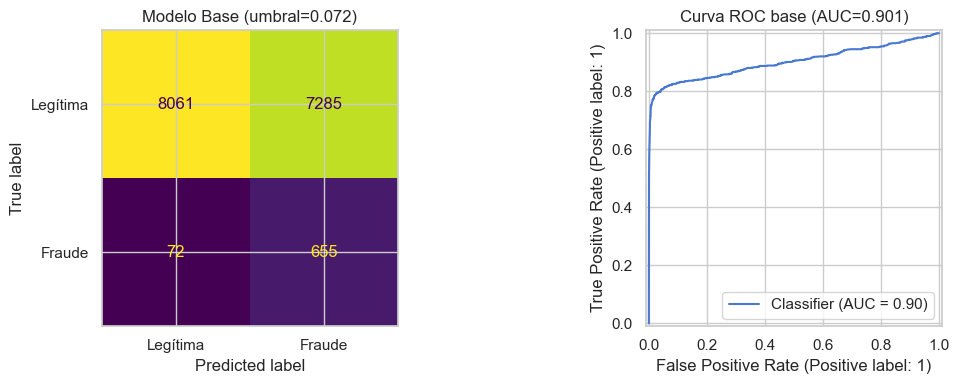

In [129]:
# buscando un umbral donde recall >= 90%
idx_90 = np.where(recall_arr >= 0.90)[0]
if len(idx_90) > 0:
    thresh_90 = thresholds_arr[idx_90[-1]]
else:
    thresh_90 = 0.5

y_pred_90 = (y_proba_base >= thresh_90).astype(int)
TP = ((y_pred_90 == 1) & (y_test == 1)).sum()
FP = ((y_pred_90 == 1) & (y_test == 0)).sum()
FN = ((y_pred_90 == 0) & (y_test == 1)).sum()

recall_actual  = TP / (TP + FN) if (TP + FN) > 0 else 0
fp_ratio       = FP / (TP + FP) if (TP + FP) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_90, display_labels=['Legítima','Fraude'],
    ax=axes[0], colorbar=False)
axes[0].set_title(f'Modelo Base (umbral={thresh_90:.3f})')
RocCurveDisplay.from_predictions(y_test, y_proba_base, ax=axes[1])
axes[1].set_title(f'Curva ROC base (AUC={roc_auc_score(y_test, y_proba_base):.3f})')
plt.tight_layout()
plt.show()

In [130]:
print('=== Modelo Base — Test (Junio 2025) ===')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_proba_base):.4f}')
print(f'Umbral @90% recall:     {thresh_90:.4f}')
print(f'Recall alcanzado:       {recall_actual:.2%}')
print(f'Ratio FP (=FP/TP+FP):   {fp_ratio:.4f}') # métrica que quiero optimizar
print(f'TP={TP}  FP={FP}  FN={FN}')

=== Modelo Base — Test (Junio 2025) ===
AUC-ROC:                0.9007
Umbral @90% recall:     0.0723
Recall alcanzado:       90.10%
Ratio FP (=FP/TP+FP):   0.9175
TP=655  FP=7285  FN=72


# TODO
- Gráfica de las iteraciones de lightGBM
- optimización de hiperparámetros
    - Optimización bayeseana (posible de usar)
- Segundo ejercicio